# Tidal analysis and prediction — Foreman method

This notebook demonstrates harmonic tidal analysis and prediction using the **Foreman (2004)** method. We use historical tide gauge data from Vlissingen (VLISSGN) to fit tidal constituents and compute the practical surge.

The Foreman method derives nodal correction factors from tabulated satellite data, which can give slightly different results from Schureman for some constituents.

**Reference:** M.G.G. Foreman (2004), *Manual for Tidal Heights Analysis and Prediction*, Institute of Ocean Sciences, Patricia Bay, Sidney B.C., Canada.

In [1]:
# Import necessary packages
using Pkg
Pkg.activate(".")
using hatyan_core
using Plots
using Dates

  Activating project at `~/deepblack/src/hatyan_core.jl.git_claude`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
# Load observed water levels from a DONAR file
obs = read_donar_timeseries("test_data/VLISSGN_obs19.txt")
@show obs
# Select a subset of the data for analysis
start_time = DateTime("1990-01-01T00:00:00")
end_time   = DateTime("1990-12-31T23:59:59")
obs1990 = select_timespan(obs, start_time, end_time)
@show obs1990
# Select a subset for the February 1990 storm event
start_time_feb1990 = DateTime("1990-02-22T00:00:00")
end_time_feb1990   = DateTime("1990-03-02T23:59:59")
obs_feb1990 = select_timespan(obs, start_time_feb1990, end_time_feb1990)
@show obs_feb1990

obs = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 166560
   Data shape: (1, 166560)
   Times: 1976-01-01T00:00:00 to 1994-12-31T23:00:00
   Locations: Vlissingen

obs1990 = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 8760
   Data shape: (1, 8760)
   Times: 1990-01-01T00:00:00 to 1990-12-31T23:00:00
   Locations: Vlissingen

obs_feb1990 = TimeSeries:
   Quantity: WATHTE (NAP)
   Source: VLISSGN
   Number of locations: 1
   Number of time points: 216
   Data shape: (1, 216)
   Times: 1990-02-22T00:00:00 to 1990-03-02T23:00:00
   Locations: Vlissingen



TimeSeries: WATHTE (NAP) from VLISSGN, with 1 locations, from 1990-02-22T00:00:00 until 1990-03-02T23:00:00.


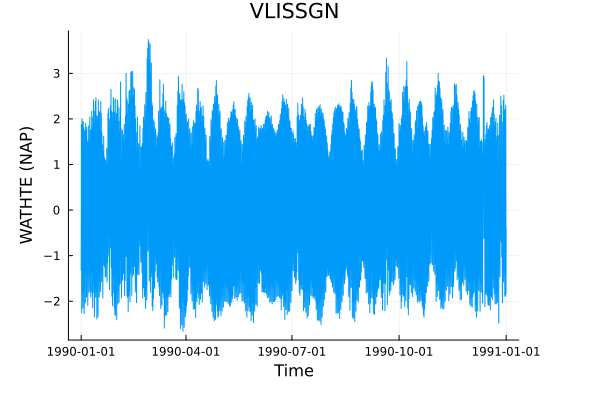

In [16]:
# Plot the observed water levels for 1990
plot(obs1990,label=false)

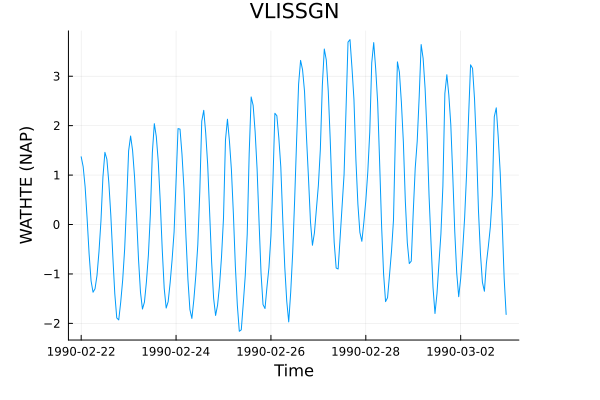

In [14]:
# Plot observed water levels during the February 1990 storm event
plot(obs_feb1990,label=false)

In [5]:
# Choose a constituent set appropriate for the record length
# "year" = 95 constituents (A0 + 94), requires ~1 year of data
const_list = constituent_list("year")

# Fit the constituents by least-squares harmonic analysis (Foreman method)
tc = analysis(obs, const_list, "foreman")
# => TidalConstituents: WATHTE (NAP) from VLISSGN | analysis(foreman)
@show tc

tc = TidalConstituents:
   Quantity:         WATHTE (NAP)
   Source:           VLISSGN | analysis(foreman)
   Locations:        Vlissingen
   N locations:      1
   N constituents:   95
   Constituents:     A0, SA, SM, Q1, O1, M1C, P1, S1, K1, 3MKS2, 3MS2, OQ2, MNS2, 2ML2S2, NLK2, MU2, N2, NU2, MSK2, MPS2, M2, MSP2, MKS2, LABDA2, 2MN2, T2, S2, K2, MSN2, 2SM2, SKM2, NO3, 2MK3, 2MP3, SO3, MK3, SK3, 4MS4, 2MNS4, 3MS4, MN4, 2MLS4, 2MSK4, M4, 3MN4, MS4, MK4, 2MSN4, S4, MNO5, 3MK5, 2MP5, 3MO5, MSK5, 3KM5, 3MNS6, 2NM6, 4MS6, 2MN6, 2MNU6, 3MSK6, M6, MSN6, MKNU6, 2MS6, 2MK6, 3MSN6, 2SM6, MSK6, 2MNO7, M7, 2MSO7, 2(MN)8, 3MN8, M8, 2MSN8, 2MNK8, 3MS8, 3MK8, 2(MS)8, 2MSK8, 3MNK9, 4MK9, 3MSK9, 4MN10, M10, 3MSN10, 4MS10, 2(MS)N10, 3M2S10, 4MSK11, M12, 4MSN12, 5MS12, 4M2S12
   Data shape:       (1, 95) [locations × constituents]



TidalConstituents: WATHTE (NAP) from VLISSGN | analysis(foreman), 1 locations, 95 constituents.


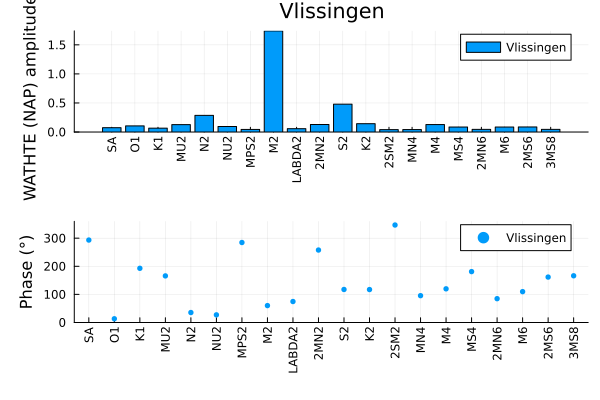

In [6]:
# Plot the tidal constituents (top 20 by amplitude, sorted by frequency)
plot(tc)

In [7]:
# Inspect results
A     = get_amplitudes(tc)
phi   = get_phases(tc)
names = get_constituent_names(tc)

i_M2 = findfirst(==("M2"), names)
println("M2 amplitude : ", A[1, i_M2], " m")
println("M2 phase     : ", phi[1, i_M2], " °")
println("Source       : ", get_source(tc))

M2 amplitude : 1.7408335 m
M2 phase     : 60.076645 °
Source       : VLISSGN | analysis(foreman)


In [8]:
# Predict water levels for 1990 using the Foreman constituents
# prediction() reads the method from tc.source automatically
pred1990 = prediction(tc, get_times(obs1990))

TimeSeries: WATHTE (NAP) from VLISSGN | analysis(foreman) | prediction, with 1 locations, from 1990-01-01T00:00:00 until 1990-12-31T23:00:00.


In [9]:
# Compute the practical surge: observed minus predicted tidal signal
surge1990 = TimeSeries(
    get_values(obs1990) .- get_values(pred1990),
    get_times(obs1990), get_names(obs1990),
    get_longitudes(obs1990), get_latitudes(obs1990),
    "surge", get_source(obs1990))

TimeSeries: surge from VLISSGN, with 1 locations, from 1990-01-01T00:00:00 until 1990-12-31T23:00:00.


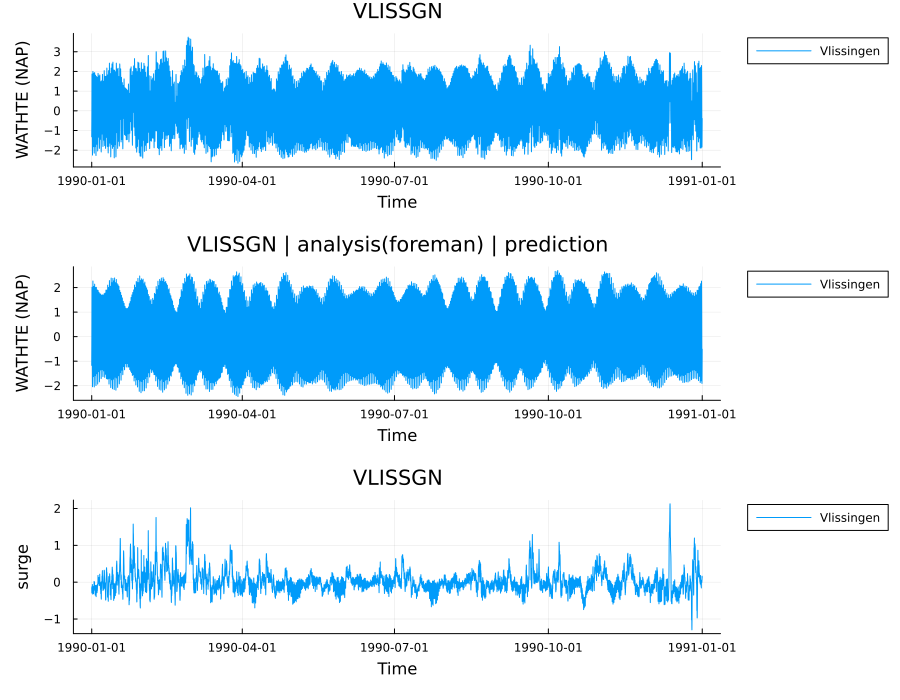

In [10]:
# Plot observed, predicted, and surge for 1990
p1 = plot(obs1990)
p2 = plot(pred1990)
p3 = plot(surge1990)
plot(p1, p2, p3, layout=(3,1), size=(900, 700))

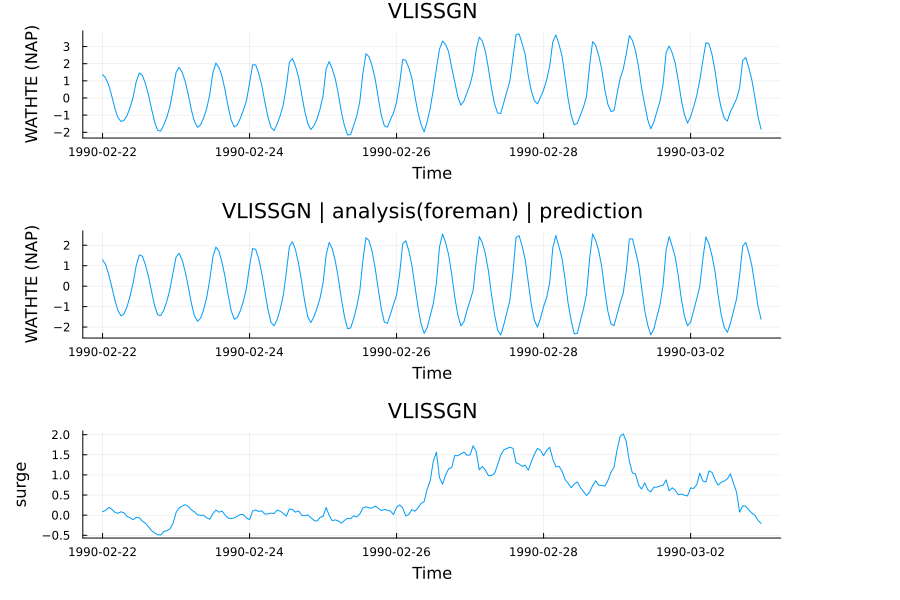

In [20]:
# Select and plot the storm event period
pred_feb1990  = select_timespan(pred1990,  start_time_feb1990, end_time_feb1990)
surge_feb1990 = select_timespan(surge1990, start_time_feb1990, end_time_feb1990)

p1 = plot(obs_feb1990,label=false)
p2 = plot(pred_feb1990,label=false)
p3 = plot(surge_feb1990,label=false)
plot(p1, p2, p3, layout=(3,1), size=(900, 600))

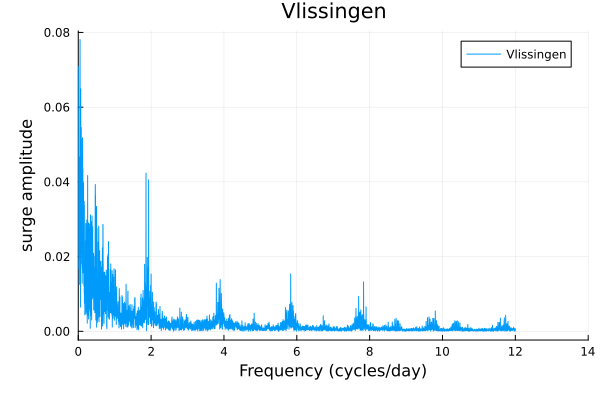

In [ ]:
# Plot the amplitude spectrum of the 1990 surge (cycles per day, up to 20 cpd)
plot(fft_series(surge1990),freq_max=12,label=false)